# NumPy Neural Network

This notebook demonstrates a fully connected neural network built from scratch using only NumPy. The implementation covers forward propagation, backpropagation, configurable activation functions, mini-batch training, and several optimisation algorithms including SGD, Momentum, and Adam. Firstly, a simple 2 feature dataset is overfitted with the decision boundary visualised. The tabular Iris dataset from scikit-learn is then used to train, validate and test a fixed layer architecture network for SGD, Momentum and Adam optimisers, testing how they compare to eachother and whether this aligns with the theoretical understanding.

The aim of the project was to understand the underlying mathematics and mechanics of neural networks by implementing them directly rather than relying on machine-learning frameworks.

In [1]:
# importing dependencies
import numpy as np
import matplotlib.pyplot as plt

import sample_data as sd
import utils
from neural_network import NeuralNetwork
from optimisers import SGD, Momentum, Adam

## 2D Classification POC with Decision Boundary Visualised

### Data Preparation and Starting Conditions

In [2]:
# import sample data
X_poc = sd.X
y_poc = sd.y

# layer architecture and activations
samples_poc = X_poc.shape[0]
features_poc = 1 if X_poc.ndim == 1 else X_poc.shape[1]

layer_architecture_poc = [features_poc, 16, 8, 8, 1]
activations_poc = ["relu", "relu", "relu", "sigmoid"]

### Build

In [3]:
model_poc = NeuralNetwork(
    layer_architecture_poc,
    activations_poc,
    loss = "BCE",
    initialisation = "He"
)

loss_data_poc = model_poc.fit(
    X_poc,
    y_poc,
    epochs=1000,
    batch_size=16,
    optimiser=Adam()
)

### Visualisation

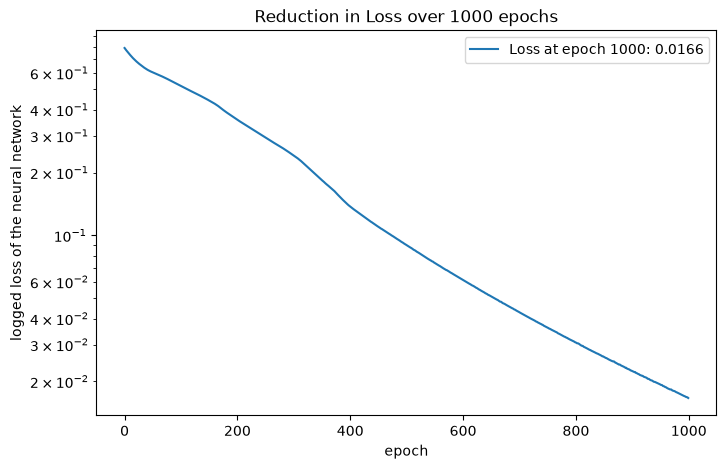

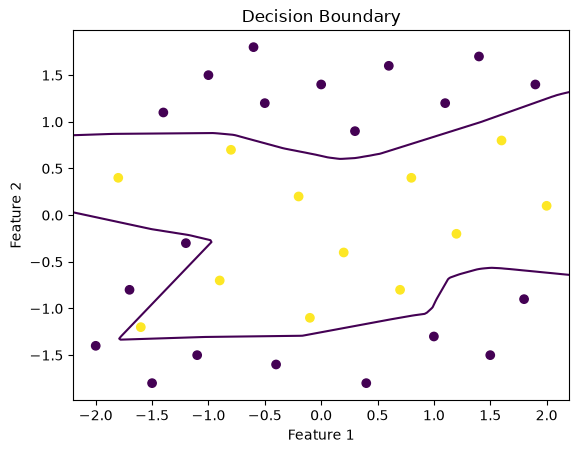

In [4]:
utils.plot_log_loss(loss_data_poc)
utils.plot_decision_boundary(X_poc, y_poc, model_poc.forward)

### POC Conclusions

The log-loss plot exhibits a roughly linear decline in loss, indicating the model is learning with the gradient descent adjusting weight and bias parameters correctly. The decision boundary plot visualises the feature values each class takes for the model at epoch 1000, where in this case, all datapoints are classsified correctly.

Switching from ReLU to GELU lead to increased overfitting, and a smoother decision boundary.
For a neuron using ReLU, the decision boundary ocurs where z = 0, and hence in our 2 feature case where: $w_1 x_1 + w_2 x_2 + b = 0$. For our plot, $y = x_2, x = x_1$. Hence, every neuron produces a straight line of $y = -\frac{w_1}{w_2}x - \frac{b}{w_2}$ active over a short region of the plane. Combining several of these ReLU neurons gives a piecewise linear decision boundary as seen above when using ReLU for hidden layer activation.
GELU uses the gaussian CDF, giving smooth non-linear transformations of z. For our small POC sample dataset, I observed GELU's greater degree or freedom gave rise to much more complex decision boundaries which had a greater tendency to overfit. 

## Building Models on the Iris Dataset for Optimiser Comparison

Here, 3 otherwise identical models take different optimisers: SGD, Momentum, Adam. The models are trained, verified and tested on an identical tabular Iris dataset from scikit-learn. The dataset contains 150 samples of iris flowers with 4 features/inputs: sepal length, sepal width, petal length and petal width. Given this information, the network classifies datapoints into one of three classes: Setosa, Versicolor or Virginica.

### Data Preparation and Starting Conditions

In [5]:
# Import scikit-learn library's load_iris module & pandas for data presentation
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold
import pandas as pd

# import Iris Dataset
iris = load_iris()
X = iris.data
y = iris.target
samples = 150

# parameters
epochs = 100
batch_size = 30
seed = 10

layer_architecture = [4, 9, 6, 6, 3]
activations = ["gelu", "gelu", "gelu", "softmax"]

Xi, Xf, yi, yf = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = seed,
    stratify=y
)

# Standardising input values
Xi_mean = Xi.mean(axis=0)
Xi_std = Xi.std(axis=0)

Xi = (Xi - Xi_mean) / Xi_std
Xf = (Xf - Xi_mean) / Xi_std

### Builds

In [6]:
# to store and display cross-validation optimiser data
optimiser_performance_df = pd.DataFrame(
    columns = ["Mean CV Accuracy", "Standard Deviation"]
)
optimiser_performance_df.index.name = "Optimiser"

# To create Cross-Validaion folds in training dataset
skf = StratifiedKFold(
    n_splits = 4,
    shuffle=True,
    random_state=seed
)

for optimiser_class in [SGD, Momentum, Adam]:

    fold_accuracy = []

    for fold, (train_indicies, test_indicies) in enumerate(skf.split(Xi, yi)):

        Xi_train = Xi[train_indicies]
        yi_train = yi[train_indicies]

        Xi_test = Xi[test_indicies]
        yi_test = yi[test_indicies]
        
        model = NeuralNetwork(
            layer_architecture,
            activations,
            loss = "CCE",
            initialisation = "He",
            seed = seed + fold
        )

        model.fit(
            Xi_train,
            yi_train,
            epochs,
            batch_size,
            optimiser_class()
        )

        model_accuracy = model.test(
            Xi_test,
            yi_test
        )
        
        fold_accuracy.append(model_accuracy)
        
    optimiser_performance_df.loc[optimiser_class.__name__] = [
        np.mean(fold_accuracy),
        np.std(fold_accuracy)
    ]

display(optimiser_performance_df)

,Mean CV Accuracy,Standard Deviation
Optimiser,,
SGD,0.533333,0.131233
Momentum,0.783333,0.050000
Adam,0.900000,0.052705


### Adam Model on Test Dataset

In [7]:
test_optimiser = Adam()

final_model = NeuralNetwork(
            layer_architecture,
            activations,
            loss="CCE"
        )

final_loss_data = final_model.fit(
    Xi,
    yi,
    epochs,
    batch_size,
    test_optimiser
)

final_model_accuracy = final_model.test(
    Xf,
    yf
)

print(f"Test accuracy using {test_optimiser.__class__.__name__}: {final_model_accuracy:.3f}")

Test accuracy using Adam: 1.000


### Iris Model Conclusions

Despite optimiser performance depending on the dataset, architecture and hyperparameters, optimiser comparison produced the same ranking than one would expect from convergence behaviour. Adam achieved the highest cross-validation accuracy, with Momentum second and SGD last. When trained on the entire training dataset, the Adam optimiser on this model gave a test accuracy of 1.